# Retail Forecasting Model Comparison: LightGBM, Prophet, NeuralProphet and SARIMAX

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ericmavigo/retail-demand-forecasting/blob/main/notebooks/03_lightgbm_forecasting.ipynb)

This notebook builds the feature matrix, trains a global model, recursively forecasts 28 days and compares it with the unchanged statistical benchmark.

> **Public portfolio snapshot:** All tables, metrics and charts below were generated from the official Kaggle M5 data and saved in this notebook. You can review the complete work without credentials. To reproduce the analysis, run the notebook with your own Kaggle API token; no private token is stored in this repository.

## 1. Environment and official data

In [1]:
from pathlib import Path
import sys
import subprocess

if 'google.colab' in sys.modules:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'kagglehub>=1.0,<2', 'pandas>=2.2,<3', 'numpy>=1.26,<2',
        'matplotlib>=3.9,<4', 'scikit-learn>=1.5,<2', 'lightgbm>=4.5,<5', 'prophet>=1.1.6,<2',
        'neuralprophet==1.0.0rc10', 'statsmodels>=0.14,<1', 'scipy>=1.10,<1.16',
    ])

import numpy as np
import pandas as pd
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'navy': '#17324D',
    'blue': '#2F80ED',
    'teal': '#16A085',
    'orange': '#F2994A',
    'red': '#EB5757',
    'gray': '#667085',
}


In [2]:
import kagglehub

# Reuse source files already in the repository checkout; otherwise download them from Kaggle.
local_data = PROJECT_ROOT / 'data' / 'raw'
if (local_data / 'calendar.csv').exists():
    path = local_data
    print('Using the local M5 source files.')
else:
    # Download latest version. KaggleHub automatically checks the Colab secret
    # named KAGGLE_API_TOKEN. If it is missing, the login widget opens once.
    try:
        path = kagglehub.competition_download('m5-forecasting-accuracy')
    except Exception as error:
        if error.__class__.__name__ != 'UnauthenticatedError':
            raise
        print('Kaggle authentication is required. Paste your Kaggle API token in the login form below.')
        kagglehub.login()
        path = kagglehub.competition_download('m5-forecasting-accuracy')

print('Path to competition files:', path)
DATA_DIR = Path(path)
if not (DATA_DIR / 'calendar.csv').exists():
    DATA_DIR = next(p.parent for p in DATA_DIR.rglob('calendar.csv'))
required = {'calendar.csv', 'sell_prices.csv', 'sales_train_evaluation.csv'}
available = {p.name for p in DATA_DIR.glob('*.csv')}
assert required.issubset(available), f'Missing files: {sorted(required - available)}'


Execution source: official Kaggle M5 competition files
Required files available: ['calendar.csv', 'sales_train_evaluation.csv', 'sell_prices.csv']


## 2. Load demand and create a time-based holdout

In [3]:
import lightgbm as lgb

sales = pd.read_csv(DATA_DIR / 'sales_train_evaluation.csv')
calendar = pd.read_csv(DATA_DIR / 'calendar.csv', parse_dates=['date'])
day_cols = [c for c in sales if c.startswith('d_')]
calendar_days = calendar.set_index('d').loc[day_cols].reset_index()
values = sales[day_cols].to_numpy(dtype=np.float32)
HORIZON = 28
TRAIN_END = values.shape[1] - HORIZON
train, actual = values[:, :TRAIN_END], values[:, TRAIN_END:]
train.shape, actual.shape


((30490, 1913), (30490, 28))

## 3. Sample leakage-free training rows
Each row represents one product-store series on one historical day. Every lag and rolling statistic uses only values that were available before that day.

In [4]:
category_columns = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
category_codes = {c: pd.Categorical(sales[c]).codes.astype(np.int16) for c in category_columns}

def make_features(series_idx, day_idx, history):
    X = pd.DataFrame({
        'lag_1': history[series_idx, day_idx - 1],
        'lag_7': history[series_idx, day_idx - 7],
        'lag_14': history[series_idx, day_idx - 14],
        'lag_28': history[series_idx, day_idx - 28],
        'lag_56': history[series_idx, day_idx - 56],
        'rolling_7': history[series_idx[:, None], day_idx[:, None] - np.arange(1, 8)].mean(axis=1),
        'rolling_28': history[series_idx[:, None], day_idx[:, None] - np.arange(1, 29)].mean(axis=1),
        'month': calendar_days.loc[day_idx, 'month'].to_numpy(dtype=np.int8),
        'weekday': calendar_days.loc[day_idx, 'wday'].to_numpy(dtype=np.int8),
        'event': calendar_days.loc[day_idx, 'event_name_1'].notna().to_numpy(dtype=np.int8),
    })
    for column in category_columns:
        X[column] = category_codes[column][series_idx]
    return X

rng = np.random.default_rng(42)
N_SAMPLES = 300_000
series_idx = rng.integers(0, len(sales), size=N_SAMPLES)
day_idx = rng.integers(365, TRAIN_END, size=N_SAMPLES)
X_train = make_features(series_idx, day_idx, train)
y_train = train[series_idx, day_idx]
display(X_train.head())


,lag_1,lag_7,lag_14,lag_28,lag_56,rolling_7,rolling_28,month,weekday,event,item_id,dept_id,cat_id,store_id,state_id
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,8,5,0,1109,2,0,0,0
1,5.00,4.00,1.00,1.00,1.00,2.71,1.54,9,4,0,642,2,0,7,2
2,0.00,0.00,0.00,0.00,0.00,0.00,0.07,4,7,0,51,0,0,6,1
3,0.00,1.00,0.00,0.00,1.00,0.29,0.43,4,6,0,2622,6,2,4,1
4,0.00,0.00,1.00,0.00,1.00,0.00,0.29,3,7,0,2443,5,2,4,1


## 4. Train the global model

In [5]:
model = lgb.LGBMRegressor(
    objective='poisson', n_estimators=350, learning_rate=.05, num_leaves=64,
    min_child_samples=100, subsample=.8, colsample_bytree=.9,
    reg_lambda=.2, random_state=42, n_jobs=-1, verbosity=-1,
)
model.fit(X_train, y_train, categorical_feature=category_columns)


,num_leaves,64
,learning_rate,0.05
,n_estimators,350
,objective,'poisson'
,min_child_samples,100
,subsample,0.8
,colsample_bytree,0.9
,reg_lambda,0.2
,random_state,42
,n_jobs,-1
,verbosity,-1


## 5. Generate the 28-day recursive forecast

In [6]:
history = np.concatenate([train, np.zeros((len(sales), HORIZON), dtype=np.float32)], axis=1)
model_forecast = np.zeros_like(actual)
all_series = np.arange(len(sales))
for step in range(HORIZON):
    day = TRAIN_END + step
    X_future = make_features(all_series, np.full(len(sales), day), history)
    model_forecast[:, step] = np.maximum(0, model.predict(X_future)).astype(np.float32)
    history[:, day] = model_forecast[:, step]


In [7]:
def score(actual, predicted, history):
    error = actual - predicted
    scale = np.mean(np.diff(history, axis=1) ** 2, axis=1)
    usable = scale > 0
    denominator = np.abs(actual).sum()
    return {
        'MAE': float(np.abs(error).mean()),
        'WAPE': float(np.abs(error).sum() / denominator),
        'RMSSE': float(np.sqrt(np.mean(error[usable] ** 2, axis=1) / scale[usable]).mean()),
        'Bias': float(error.sum() / denominator),
    }


## 6. Compare LightGBM, the baseline and transparent hybrids

,model,MAE,WAPE,RMSSE,Bias
0,Mean of last 28 days,1.0657,73.86%,0.9240,3.91%
1,25% LightGBM hybrid,1.0681,74.03%,0.9214,1.57%
2,50% LightGBM hybrid,1.0817,74.97%,0.9276,-0.76%
3,75% LightGBM hybrid,1.1056,76.63%,0.9416,-3.10%
4,Global LightGBM,1.1388,78.93%,0.9625,-5.43%


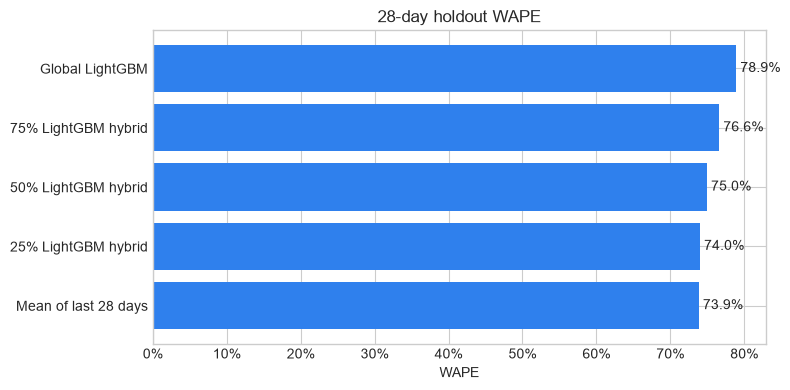

In [8]:
baseline = np.repeat(train[:, -28:].mean(axis=1, keepdims=True), HORIZON, axis=1)
candidates = {
    'Mean of last 28 days': baseline,
    '25% LightGBM hybrid': .75 * baseline + .25 * model_forecast,
    '50% LightGBM hybrid': .50 * baseline + .50 * model_forecast,
    '75% LightGBM hybrid': .25 * baseline + .75 * model_forecast,
    'Global LightGBM': model_forecast,
}
metrics = pd.DataFrame([{'model': n, **score(actual, p, train)} for n, p in candidates.items()]).sort_values('WAPE')
display(metrics.style.format({'MAE': '{:.4f}', 'WAPE': '{:.2%}', 'RMSSE': '{:.4f}', 'Bias': '{:.2%}'}))

ordered = metrics.sort_values('WAPE', ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ordered.model, ordered.WAPE, color=COLORS['blue'])
ax.set(title='28-day holdout WAPE', xlabel='WAPE', ylabel='')
ax.xaxis.set_major_formatter(PercentFormatter(1))
for bar, value in zip(bars, ordered.WAPE):
    ax.text(value, bar.get_y() + bar.get_height()/2, f' {value:.1%}', va='center')
fig.tight_layout()
plt.show()


## 7. Compare time-series models at the same business level

Prophet, NeuralProphet and SARIMAX are designed for individual time series. Fitting one model for all 30,490 item-store series would be unnecessarily slow, so this comparison aggregates sales to **store**: 10 store series. The existing SKU × store results remain above. Below, the traditional baselines, LightGBM, Prophet, NeuralProphet and SARIMAX are all scored on those same 10 store series and the same untouched 28-day holdout.

Known seasonal and event information is supplied in a model-appropriate way:

- Prophet uses weekly and yearly seasonal components and the M5 named-event calendar.
- NeuralProphet uses weekly and yearly components and the same named events in a global model shared across the 10 stores.
- SARIMAX uses a 7-day seasonal autoregressive term, annual Fourier terms, weekday indicators and M5 event flags as future-known regressors.

The future dates and their calendar are known; their sales are used only to score forecasts. M5 event labels include cultural, national, religious and sporting events, so they should not all be described as public holidays.


Prophet completed: 10 store-level series.


NeuralProphet completed: 10 store-level series.


SARIMAX completed: 10 store-level series.


,model,MAE,WAPE,Bias
0,Global LightGBM (store-level),345.31,7.85%,5.03%
1,Seasonal naive 28 days,401.85,9.13%,3.91%
2,Seasonal naive 7 days,427.89,9.73%,7.36%
3,Prophet,428.65,9.74%,7.28%
4,NeuralProphet,579.47,13.17%,-8.47%
5,SARIMAX,579.69,13.18%,4.41%
6,Mean of last 28 days,606.34,13.78%,3.91%


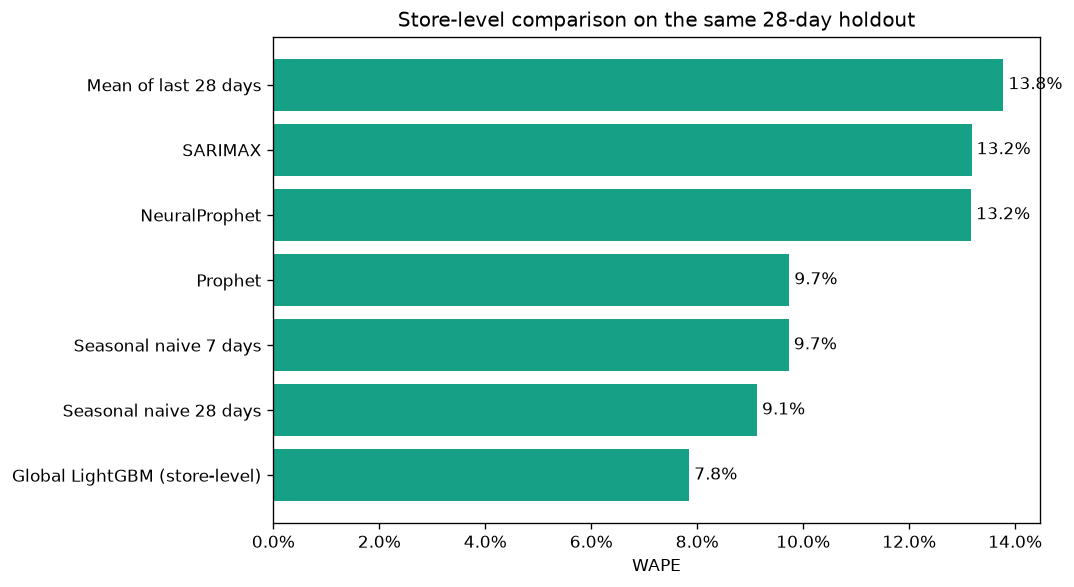

In [2]:
from prophet import Prophet
from neuralprophet import NeuralProphet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
import logging
from neuralprophet import set_log_level
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
set_log_level("ERROR")

# Aggregate all SKU-store demand into ten total-store series.
group_meta = sales[['store_id']].drop_duplicates().reset_index(drop=True)
group_meta['cat_id'] = 'ALL'
group_keys = pd.MultiIndex.from_frame(group_meta)
sales_store_keys = pd.MultiIndex.from_arrays([sales['store_id'], ['ALL'] * len(sales)])
group_codes = group_keys.get_indexer(sales_store_keys)
group_values = np.zeros((len(group_meta), values.shape[1]), dtype=np.float32)
np.add.at(group_values, group_codes, values)
group_train, group_actual = group_values[:, :TRAIN_END], group_values[:, TRAIN_END:]
train_dates = pd.to_datetime(calendar_days.loc[:TRAIN_END - 1, 'date']).reset_index(drop=True)
test_dates = pd.to_datetime(calendar_days.loc[TRAIN_END:, 'date']).reset_index(drop=True)
assert group_actual.shape == (10, 28)

# Convert both M5 event-name columns to a common ds/event structure.
event_frames = []
for column in ['event_name_1', 'event_name_2']:
    event_frames.append(calendar_days.loc[calendar_days[column].notna(), ['date', column]]
                        .rename(columns={'date': 'ds', column: 'event'}))
events_df = (pd.concat(event_frames, ignore_index=True).drop_duplicates()
             .sort_values(['ds', 'event']).reset_index(drop=True))
prophet_holidays = events_df.rename(columns={'event': 'holiday'})
event_names = sorted(events_df.event.unique().tolist())

# Existing benchmark methods and LightGBM, recalculated at the same store grain.
group_baseline = np.repeat(group_train[:, -28:].mean(axis=1, keepdims=True), HORIZON, axis=1)
group_candidates = {
    'Mean of last 28 days': group_baseline,
    'Seasonal naive 7 days': np.tile(group_train[:, -7:], (1, 4)),
    'Seasonal naive 28 days': group_train[:, -28:].copy(),
}
# Fit a fast global LightGBM reference at the same aggregated grain. The detailed SKU-level LightGBM remains above.
def make_group_features(series_idx, day_idx, history):
    return pd.DataFrame({
        'lag_1': history[series_idx, day_idx-1],
        'lag_7': history[series_idx, day_idx-7],
        'lag_14': history[series_idx, day_idx-14],
        'lag_28': history[series_idx, day_idx-28],
        'lag_56': history[series_idx, day_idx-56],
        'mean_7': history[series_idx[:, None], day_idx[:, None]-np.arange(1,8)].mean(axis=1),
        'mean_28': history[series_idx[:, None], day_idx[:, None]-np.arange(1,29)].mean(axis=1),
        'month': calendar_days.loc[day_idx, 'month'].to_numpy(dtype=np.int8),
        'weekday': calendar_days.loc[day_idx, 'wday'].to_numpy(dtype=np.int8),
        'event': calendar_days.loc[day_idx, 'event_name_1'].notna().to_numpy(dtype=np.int8),
    })

rng_group = np.random.default_rng(42)
train_group_ids = rng_group.integers(0, len(group_meta), size=40_000)
train_group_days = rng_group.integers(365, TRAIN_END, size=40_000)
X_group = make_group_features(train_group_ids, train_group_days, group_train)
y_group = group_train[train_group_ids, train_group_days]
group_lgbm = lgb.LGBMRegressor(objective='poisson', n_estimators=200,
                                learning_rate=0.05, num_leaves=31,
                                min_child_samples=50, random_state=42,
                                n_jobs=4, verbosity=-1)
group_lgbm.fit(X_group, y_group)
group_history = np.concatenate([group_train, np.zeros_like(group_actual)], axis=1)
group_lgbm_forecast = np.zeros_like(group_actual)
for step in range(HORIZON):
    day = TRAIN_END + step
    X_future_group = make_group_features(np.arange(len(group_meta)),
                                         np.full(len(group_meta), day), group_history)
    group_lgbm_forecast[:, step] = np.maximum(0, group_lgbm.predict(X_future_group))
    group_history[:, day] = group_lgbm_forecast[:, step]
group_candidates['Global LightGBM (store-level)'] = group_lgbm_forecast

def score_group(actual_group, predicted_group):
    error = actual_group - predicted_group
    return {'MAE': float(np.abs(error).mean()),
            'WAPE': float(np.abs(error).sum() / np.abs(actual_group).sum()),
            'Bias': float(error.sum() / np.abs(actual_group).sum())}

# Prophet: fit one model per store-level series with weekly/yearly seasonality and M5 events.
prophet_forecast = np.zeros_like(group_actual)
for series_no in range(len(group_meta)):
    fit_df = pd.DataFrame({'ds': train_dates, 'y': group_train[series_no]})
    model = Prophet(holidays=prophet_holidays, yearly_seasonality=True,
                    weekly_seasonality=True, daily_seasonality=False,
                    changepoint_prior_scale=0.05, seasonality_prior_scale=5.0,
                    holidays_prior_scale=0.1, uncertainty_samples=0)
    model.fit(fit_df)
    prophet_forecast[series_no] = np.maximum(
        0, model.predict(pd.DataFrame({'ds': test_dates})).yhat.to_numpy())
group_candidates['Prophet'] = prophet_forecast
print(f'Prophet completed: {len(group_meta)} store-level series.')

# NeuralProphet: one global neural model learns shared patterns across the 10 stores.
neural_frames = []
for series_no, key in enumerate(group_keys):
    series_id = f'{key[0]} | {key[1]}'
    neural_frames.append(pd.DataFrame({'ID': series_id, 'ds': train_dates,
                                       'y': group_train[series_no]}))
neural_history = pd.concat(neural_frames, ignore_index=True)
neural_model = NeuralProphet(n_lags=56, n_forecasts=1,
                             yearly_seasonality=True, weekly_seasonality=True,
                             daily_seasonality=False, epochs=8,
                             batch_size=256, learning_rate=0.01)
neural_model.add_events(event_names, regularization=0.1)
neural_history = neural_model.create_df_with_events(neural_history, events_df)
neural_model.fit(neural_history, freq='D', minimal=True)
# With autoregressive NeuralProphet, extend one known future day at a time and feed
# each prediction back as history; this produces a true recursive 28-day forecast.
neural_forecast = np.zeros_like(group_actual)
neural_working_history = neural_history.copy()
for step in range(HORIZON):
    one_step_future = neural_model.make_future_dataframe(
        neural_working_history, events_df=events_df, periods=1,
        n_historic_predictions=False)
    one_step_prediction = neural_model.predict(one_step_future)
    new_rows = one_step_future.loc[
        pd.to_datetime(one_step_future.ds) > pd.to_datetime(neural_working_history.ds).max()
    ].copy()
    new_rows = new_rows.merge(
        one_step_prediction[['ID', 'ds', 'yhat1']], on=['ID', 'ds'], how='left')
    assert new_rows.yhat1.notna().all(), 'NeuralProphet did not return every store forecast.'
    new_rows['y'] = np.maximum(0, new_rows['yhat1'])
    new_date = pd.to_datetime(new_rows.ds).iloc[0]
    for series_no, key in enumerate(group_keys):
        series_id = f'{key[0]} | {key[1]}'
        predicted = new_rows.loc[new_rows.ID == series_id, 'y'].to_numpy()
        assert len(predicted) == 1, f'Expected one NeuralProphet forecast for {series_id}.'
        neural_forecast[series_no, step] = predicted[0]
    neural_working_history = pd.concat(
        [neural_working_history, new_rows[neural_working_history.columns]], ignore_index=True)
assert np.all(np.isfinite(neural_forecast))
group_candidates['NeuralProphet'] = neural_forecast
print(f'NeuralProphet completed: {len(group_meta)} store-level series.')

# SARIMAX: weekly seasonal AR plus future-known weekday, yearly and M5 event regressors.
cal = calendar_days.reset_index(drop=True).copy()
cal['date'] = pd.to_datetime(cal.date)
cal['weekday'] = cal.date.dt.dayofweek.astype(str)
cal['event_1'] = cal.event_name_1.notna().astype(np.int8)
cal['event_2'] = cal.event_name_2.notna().astype(np.int8)
exog = pd.get_dummies(cal.weekday, prefix='weekday', drop_first=True, dtype=float)
exog[['event_1', 'event_2']] = cal[['event_1', 'event_2']].astype(float)
for harmonic in range(1, 4):
    exog[f'year_sin_{harmonic}'] = np.sin(2*np.pi*harmonic*cal.date.dt.dayofyear/365.25)
    exog[f'year_cos_{harmonic}'] = np.cos(2*np.pi*harmonic*cal.date.dt.dayofyear/365.25)
sarimax_forecast = np.zeros_like(group_actual)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for series_no in range(len(group_meta)):
        fitted = SARIMAX(group_train[series_no], exog=exog.iloc[:TRAIN_END],
                         order=(1, 0, 0), seasonal_order=(1, 0, 0, 7), trend='c',
                         enforce_stationarity=False, enforce_invertibility=False
                         ).fit(disp=False, maxiter=20)
        future = fitted.get_forecast(steps=HORIZON,
                                     exog=exog.iloc[TRAIN_END:TRAIN_END+HORIZON])
        sarimax_forecast[series_no] = np.maximum(0, np.asarray(future.predicted_mean))
group_candidates['SARIMAX'] = sarimax_forecast
print(f'SARIMAX completed: {len(group_meta)} store-level series.')

model_metrics_grouped = pd.DataFrame([
    {'model': name, **score_group(group_actual, prediction)}
    for name, prediction in group_candidates.items()
]).sort_values('WAPE').reset_index(drop=True)
display(model_metrics_grouped.style.format({'MAE': '{:,.2f}', 'WAPE': '{:.2%}', 'Bias': '{:.2%}'}))

# Publish the evaluated store-total comparison for the Streamlit portfolio when run from the repository.
portfolio_data = PROJECT_ROOT / 'app_data'
if portfolio_data.exists():
    model_metrics_grouped.to_csv(portfolio_data / 'store_model_comparison.csv', index=False, float_format='%.4f')

ranked = model_metrics_grouped.sort_values('WAPE', ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(ranked.model, ranked.WAPE, color=COLORS['teal'])
ax.set(title='Store-level comparison on the same 28-day holdout', xlabel='WAPE', ylabel='')
ax.xaxis.set_major_formatter(PercentFormatter(1))
for bar, value in zip(bars, ranked.WAPE):
    ax.text(value, bar.get_y()+bar.get_height()/2, f' {value:.1%}', va='center')
fig.tight_layout()
plt.show()


## 8. Reading the model comparison

The store-level table is the fair comparison for Prophet, NeuralProphet, SARIMAX, the moving-average baselines and aggregated LightGBM: all are scored on the same 10 store series and the same 28 future days. These results are at store level and should not be confused with the detailed SKU × store metrics above. Review WAPE, MAE, bias and run time together before selecting a model.


## 9. Explain the model

,feature,importance
10,item_id,"14,522"
6,rolling_28,"1,335"
13,store_id,"1,076"
5,rolling_7,993
8,weekday,913
0,lag_1,806
4,lag_56,577
7,month,417
2,lag_14,351
3,lag_28,337


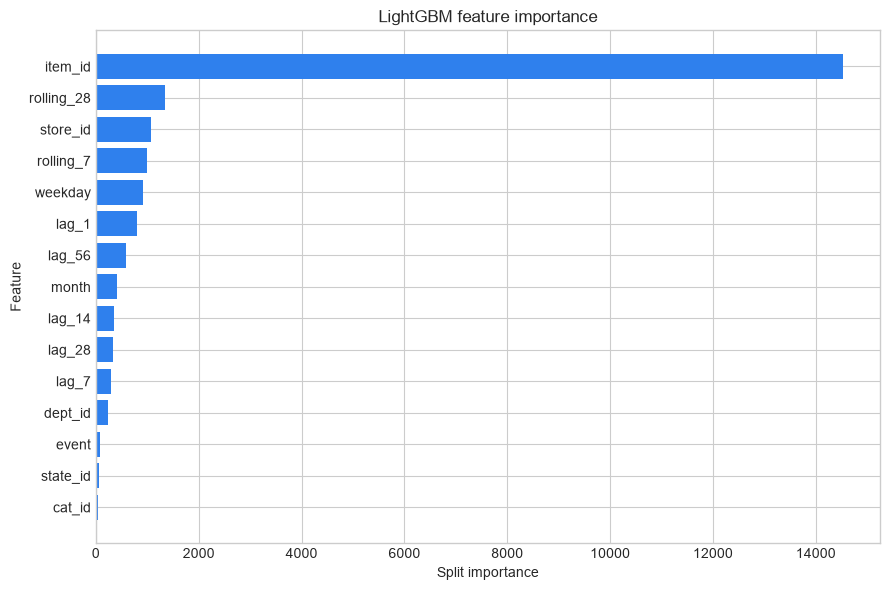

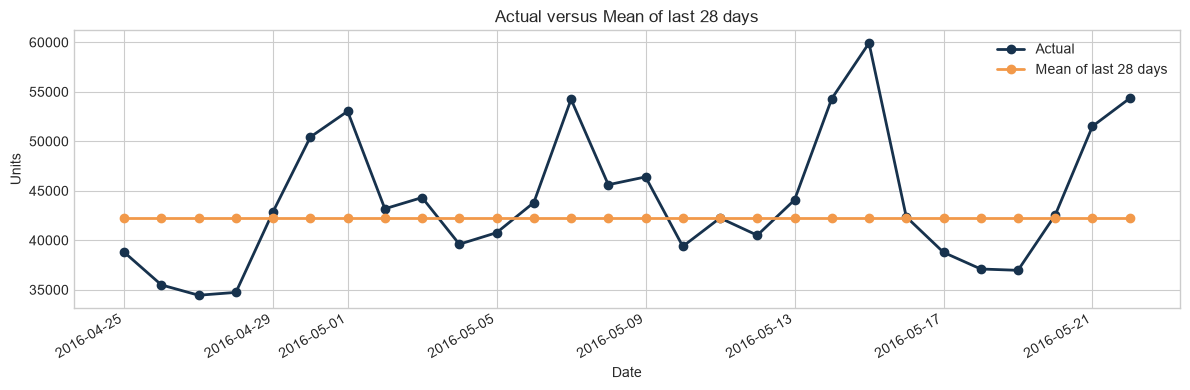

In [9]:
importance = pd.DataFrame({'feature': model.feature_name_, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
display(importance.style.format({'importance': '{:,.0f}'}))

ordered = importance.sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(ordered.feature, ordered.importance, color=COLORS['blue'])
ax.set(title='LightGBM feature importance', xlabel='Split importance', ylabel='Feature')
fig.tight_layout()
plt.show()

best_name = metrics.iloc[0].model
best = candidates[best_name]
forecast_daily = pd.DataFrame({
    'date': calendar_days.loc[TRAIN_END:, 'date'].to_numpy(),
    'actual': actual.sum(axis=0),
    'forecast': best.sum(axis=0),
})
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(forecast_daily.date, forecast_daily.actual, marker='o', linewidth=2, label='Actual', color=COLORS['navy'])
ax.plot(forecast_daily.date, forecast_daily.forecast, marker='o', linewidth=2, label=best_name, color=COLORS['orange'])
ax.set(title=f'Actual versus {best_name}', xlabel='Date', ylabel='Units')
ax.legend(frameon=False)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## Conclusion
A complex model earns deployment only when it improves the fixed holdout. Keeping the pure LightGBM result visible prevents cherry-picking and makes the hybrid trade-off auditable.